# Systems Conference Topic Explorer

Five interactive visualisations of how systems research topics evolved from 2006 to 2025,
based on the DBLP bibliography dump (4,654 papers across 84 conference editions).

**Cell 3** calls the Anthropic API to name clusters — results cached in `data/cluster_labels.json`.

In [1]:
import sys
from pathlib import Path

repo = Path.cwd().parent
if str(repo / "src") not in sys.path:
    sys.path.insert(0, str(repo / "src"))

from dotenv import find_dotenv, load_dotenv
load_dotenv(find_dotenv())

import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

from viz_sys_conferences.viz_data import load_editions
from viz_sys_conferences.viz_plots import (
    papers_over_time,
    keyword_heatmap_matrix,
    topic_trends_from_embeddings,
    conference_similarity,
)

DATA_DIR = repo / "data"
editions = load_editions(DATA_DIR)
print(f"Loaded {len(editions)} editions, {sum(len(e['papers']) for e in editions)} papers")

Loaded 84 editions, 4654 papers


## 1 · Papers over time

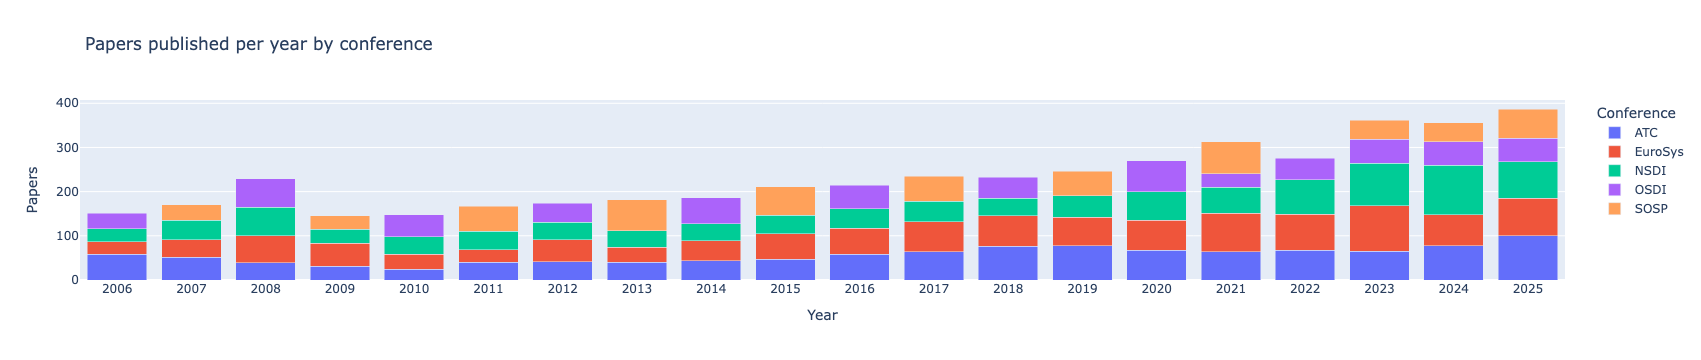

In [2]:
df = papers_over_time(editions)

fig = px.bar(
    df, x="year", y="paper_count", color="conference",
    barmode="stack",
    title="Papers published per year by conference",
    labels={"paper_count": "Papers", "year": "Year", "conference": "Conference"},
)
fig.update_layout(xaxis=dict(dtick=1), hovermode="x unified")
fig.show()

## 2 · Paper title keyword heatmap

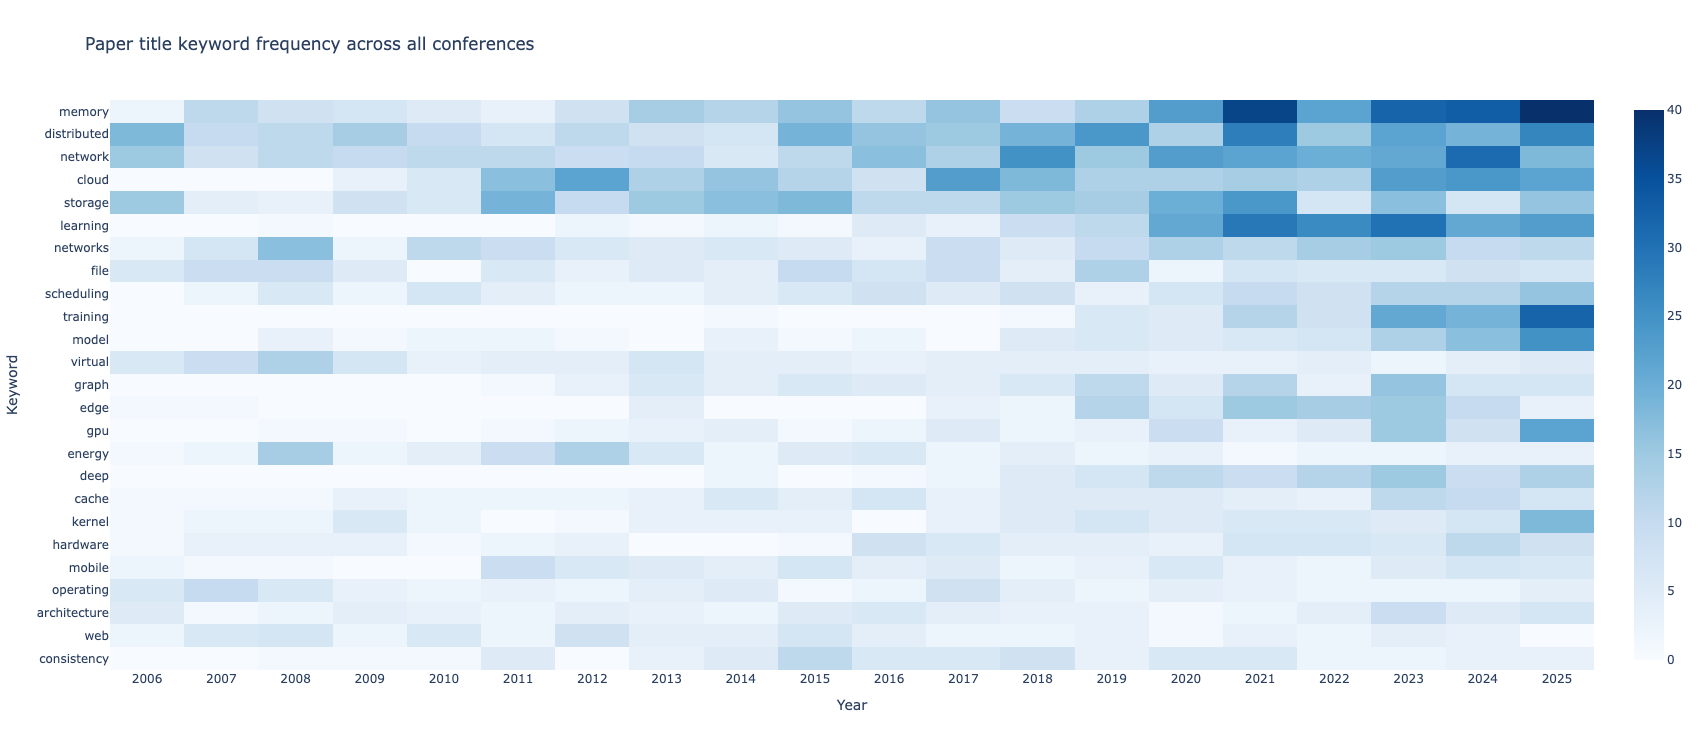

In [3]:
matrix = keyword_heatmap_matrix(editions, top_n=25)

fig = go.Figure(go.Heatmap(
    z=matrix.values,
    x=[str(y) for y in matrix.columns],
    y=matrix.index.tolist(),
    colorscale="Blues",
    hovertemplate="Keyword: %{y}<br>Year: %{x}<br>Count: %{z}<extra></extra>",
))
fig.update_layout(
    title="Paper title keyword frequency across all conferences",
    xaxis_title="Year",
    yaxis_title="Keyword",
    height=750,
    yaxis=dict(autorange="reversed"),
)
fig.show()

## 3 · Topic trend lines

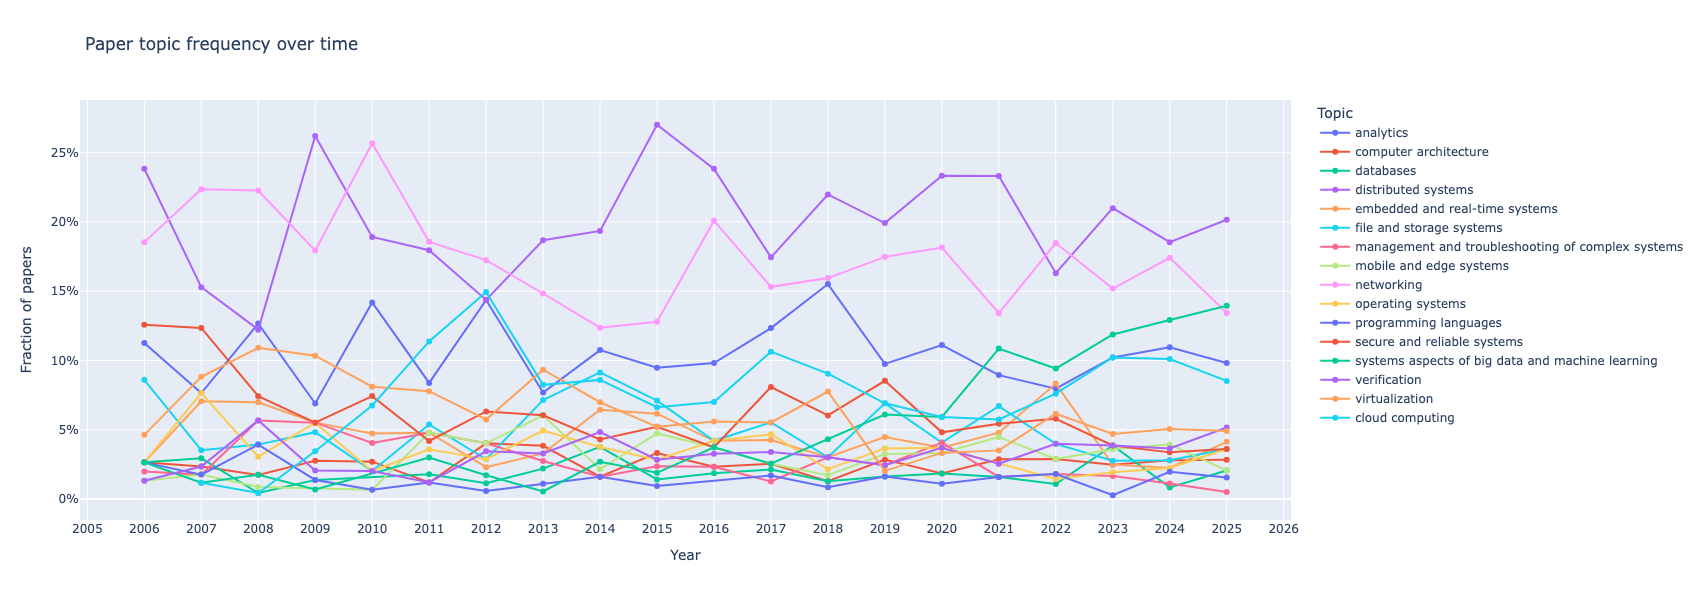

In [4]:
import plotly.graph_objects as go

trends = topic_trends_from_embeddings(DATA_DIR / "embeddings.npz")

topics_ordered = trends["topic"].unique().tolist()

# 16 visually distinct colours
colors = (
    px.colors.qualitative.Dark24 + px.colors.qualitative.Light24
)[:len(topics_ordered)]

# 8 distinct marker symbols, cycled
symbols = [
    "circle", "square", "diamond", "cross",
    "triangle-up", "triangle-down", "star", "hexagon",
]

fig = go.Figure()
for i, topic in enumerate(topics_ordered):
    df_t = trends[trends["topic"] == topic]
    fig.add_scatter(
        x=df_t["year"], y=df_t["frequency"],
        mode="lines+markers",
        name=topic,
        line=dict(color=colors[i]),
        marker=dict(symbol=symbols[i % len(symbols)], size=8, color=colors[i]),
    )

fig.update_layout(
    title="Paper topic frequency over time",
    xaxis=dict(dtick=1, title="Year"),
    yaxis=dict(tickformat=".0%", title="Fraction of papers"),
    hovermode="x unified",
    height=600,
    legend=dict(itemsizing="constant"),
)
fig.show()

## 4 · Determinism or deterministic in paper titles

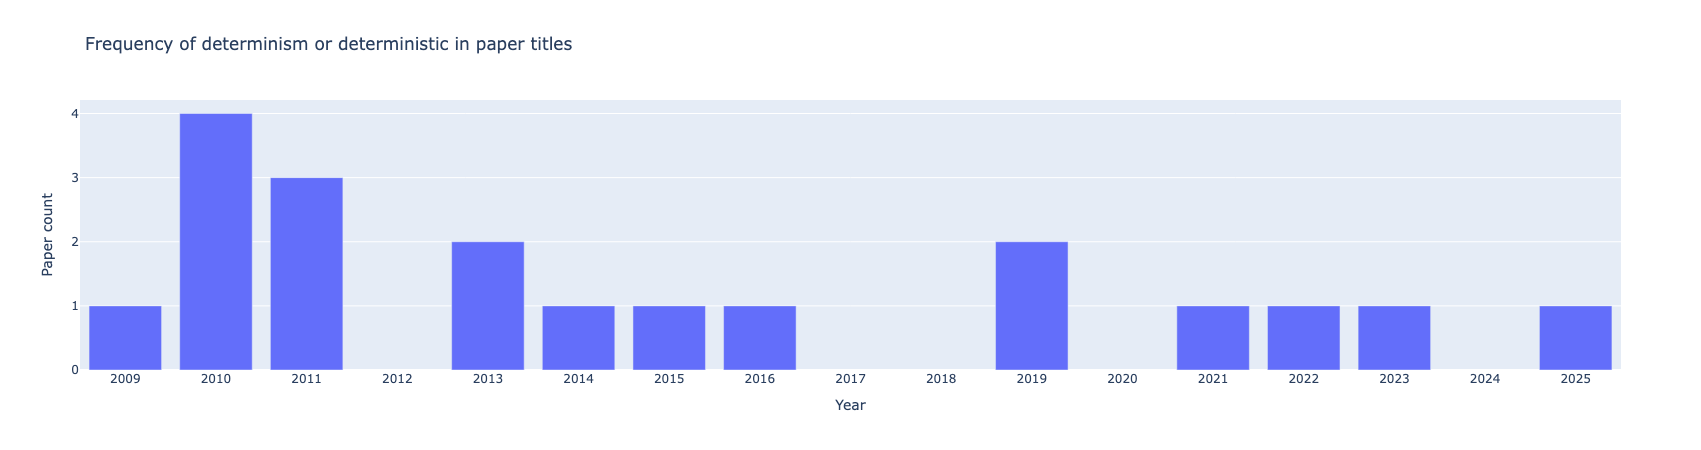

In [5]:
from collections import defaultdict

counts_by_year: dict[int, int] = defaultdict(int)

for e in editions:
    for p in e["papers"]:
        if "determinis" in p["title"].lower():
            counts_by_year[e["year"]] += 1

years = sorted(counts_by_year)
abs_counts = [counts_by_year[y] for y in years]

import plotly.graph_objects as go
fig = go.Figure()
fig.add_bar(x=years, y=abs_counts, name="Paper count")
fig.update_layout(
    title="Frequency of determinism or deterministic in paper titles",
    xaxis=dict(dtick=1, title="Year"),
    yaxis=dict(title="Paper count"),
    hovermode="x unified",
    height=450,
)
fig.show()

## 5 · Conference topic-overlap

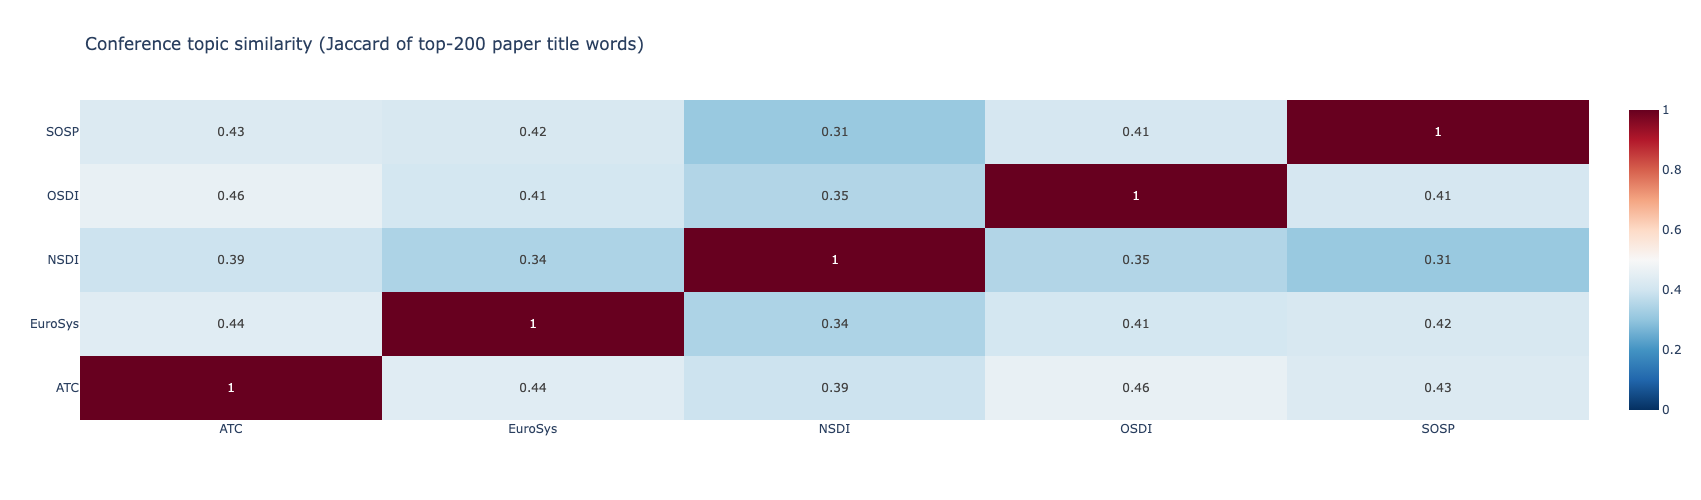

In [6]:
sim = conference_similarity(editions)
confs = sim.index.tolist()

fig = go.Figure(go.Heatmap(
    z=sim.values,
    x=confs,
    y=confs,
    colorscale="RdBu",
    reversescale=True,
    zmin=0, zmax=1,
    text=np.round(sim.values, 2),
    texttemplate="%{text}",
    hovertemplate="%{y} vs %{x}: %{z:.3f}<extra></extra>",
))
fig.update_layout(
    title="Conference topic similarity (Jaccard of top-200 paper title words)",
    height=500,
)
fig.show()